# Context-Aware Political Reddit Classification (CNN-LSTM)

Improvement project over the Shirley Cheng (Stanford CS224N) baseline.
Core idea: enrich short Reddit comments with their parent post text using a `[SEP]` marker, embed with CBOW Word2Vec trained on the in-domain training corpus, and classify with a CNN-LSTM in Keras.

**Labels:** 0 = Democrat, 1 = Republican.


## 1. Imports, Config, and Reproducibility


In [1]:
import os
import random
import pickle
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional,
    GlobalMaxPooling1D, Concatenate, Lambda, Layer, Dense,
    Dropout, SpatialDropout1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TerminateOnNaN,
)

for resource in [
    'punkt', 'punkt_tab', 'stopwords',
    'wordnet', 'omw-1.4',
    'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
]:
    try:
        nltk.download(resource, quiet=True)
    except Exception as e:
        print(f'Failed to download {resource}: {e}')


In [2]:
SEED = 42

def set_global_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

set_global_seeds(SEED)

CONFIG = {
    'DATA_PATH': r'D:\PROJECTS\NLP - PROJECT\political_reddit_context_100k.csv',
    'ARTIFACTS_DIR': 'artifacts',
    'SEP_TOKEN': '[SEP]',
    'SEP_PLACEHOLDER': 'xxsepxx',
    'MAX_LEN': 128,                # recomputed from train P90 in section 8
    'MAX_LEN_FLOOR': 96,
    'MAX_LEN_CAP': 192,
    'MIN_TRAIN_TOKENS': 3,         # train-only short-sample filter
    'EMBED_DIM': 100,
    'W2V_WINDOW': 10,              # was 5  — enriched sequences are longer
    'W2V_MIN_COUNT': 1,            # was 2  — raise coverage
    'W2V_EPOCHS': 20,              # was 10 — CBOW benefits from more passes
    'W2V_SG': 0,                   # CBOW (sg=0) — mandatory
    'BATCH_SIZE': 64,
    'EPOCHS': 30,
    'LR': 0.001,
    'CONV_FILTERS': 128,
    'KERNEL_SIZE': 5,
    'POOL_SIZE': 2,
    'LSTM_UNITS': 128,
    'ATTENTION_UNITS': 64,         # SimpleAttention hidden width
    'DROPOUT': 0.4,                # was 0.3 — wider head absorbs more capacity
    'SPATIAL_DROPOUT': 0.2,
    'PATIENCE_ES': 6,              # was 4
    'PATIENCE_LR': 3,              # was 2
    'TEST_SIZE': 0.10,
    'VAL_SIZE_OF_REMAINDER': 1.0 / 9.0,
    'SEED': SEED,
}

Path(CONFIG['ARTIFACTS_DIR']).mkdir(parents=True, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('Seed:', SEED)
print('Artifacts dir:', os.path.abspath(CONFIG['ARTIFACTS_DIR']))


TensorFlow: 2.15.0
GPUs: []
Seed: 42
Artifacts dir: d:\PROJECTS\NLP - PROJECT\artifacts


## 2. Data Loading


In [3]:
df = pd.read_csv(
    CONFIG['DATA_PATH'],
    dtype={'id': str, 'root': str, 'reply_to': str},
)
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nFirst rows:')
df.head()


Shape: (100000, 5)

Dtypes:
id          object
root        object
reply_to    object
text        object
label        int64
dtype: object

First rows:


,id,root,reply_to,text,label
0,e0icvw4,8q9bva,e0iaqq4,Do you consider CNN to be?,1
1,cwywp2l,3skvz0,cwyw88z,Where did the liberal touch you? \n\nShow me ...,1
2,d9xj9u3,5ck8j0,5ck8j0,We do need to apologize for some things. The ...,0
3,dwiox1t,881zb4,dwhlw01,My old high school had a bunch of pickup truck...,1
4,c6iviy1,10zuhi,c6i9vp6,You can...until you can't. What you're describ...,1


## 3. Dataset Integrity Checks


Label values: [0, 1]

Class counts:
label
1    50000
0    50000
Name: count, dtype: int64

Null counts per column:
id             0
root           0
reply_to    1129
text           0
label          0
dtype: int64

[deleted] in text: 0
[removed] in text: 0

Duplicate ids: 0

Character-length stats per class:
         count       mean         std  min   25%    50%    75%      max
label                                                                  
0      50000.0  270.96002  492.701436  3.0  59.0  132.0  296.0  20511.0
1      50000.0  318.31910  478.400296  3.0  77.0  167.0  366.0  13178.0


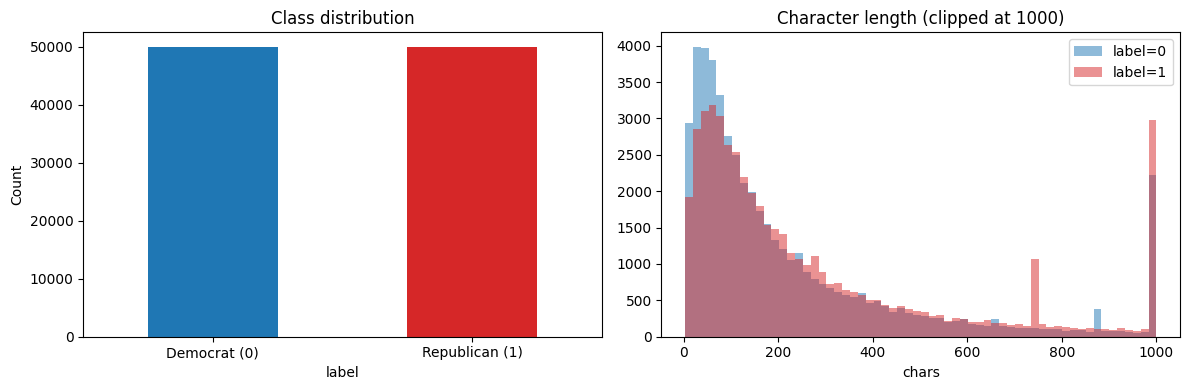

In [4]:
required = {'text', 'label', 'id', 'root', 'reply_to'}
missing = required - set(df.columns)
assert not missing, f'Missing columns: {missing}'

df['label'] = df['label'].astype(int)
print('Label values:', sorted(df['label'].unique()))
assert set(df['label'].unique()) == {0, 1}

print('\nClass counts:')
print(df['label'].value_counts())

print('\nNull counts per column:')
print(df.isnull().sum())

deleted_count = (df['text'] == '[deleted]').sum()
removed_count = (df['text'] == '[removed]').sum()
print(f'\n[deleted] in text: {deleted_count}')
print(f'[removed] in text: {removed_count}')

dup_ids = df['id'].duplicated().sum()
print(f'\nDuplicate ids: {dup_ids}')

df['char_len'] = df['text'].astype(str).str.len()
print('\nCharacter-length stats per class:')
print(df.groupby('label')['char_len'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['tab:blue', 'tab:red']
)
axes[0].set_xticklabels(['Democrat (0)', 'Republican (1)'], rotation=0)
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')

for lbl, color in [(0, 'tab:blue'), (1, 'tab:red')]:
    axes[1].hist(
        df.loc[df['label'] == lbl, 'char_len'].clip(upper=1000),
        bins=60, alpha=0.5, label=f'label={lbl}', color=color,
    )
axes[1].set_title('Character length (clipped at 1000)')
axes[1].legend()
axes[1].set_xlabel('chars')
plt.tight_layout()
plt.show()


## 4. Context Matching Logic


In [5]:
def is_usable_text(t):
    if not isinstance(t, str):
        return False
    s = t.strip()
    if s == '' or s == '[deleted]' or s == '[removed]':
        return False
    return True


# ID normalization: ensure clean string keys before building any lookup.
# Reddit IDs have no whitespace, but CSV round-trips and pandas dtype quirks
# can introduce stray padding or stringified "nan"/"None" tokens that silently
# break dict lookups.
for col in ['id', 'root', 'reply_to']:
    df[col] = df[col].astype('string').str.strip()
df.loc[df['reply_to'].isin(['', 'nan', 'None', 'NaN', '<NA>']), 'reply_to'] = pd.NA
df.loc[df['root'].isin(['', 'nan', 'None', 'NaN', '<NA>']), 'root'] = pd.NA


def is_main_post(row):
    return (row['id'] == row['root']) or pd.isna(row['reply_to'])


# --- Full id -> text lookup over EVERY usable row ---
# The original implementation only indexed top-level posts (rows where
# id == root). That capped the achievable context hit rate at ~2.3 % because
# most comments reply to OTHER comments, not to the root submission.
# Indexing every usable row lets resolve_context() walk reply_to first and
# fall back to root, dramatically raising coverage.
usable_mask = df['text'].apply(is_usable_text)
usable_df = df[usable_mask]

id_to_text = {}
conflicts = 0
for rid, txt in zip(usable_df['id'].tolist(), usable_df['text'].tolist()):
    if rid is pd.NA or rid is None:
        continue
    if rid in id_to_text:
        conflicts += 1
        continue
    id_to_text[rid] = txt

# Backward-compatible post-only lookup, kept for diagnostics/comparison only.
main_post_mask = df.apply(is_main_post, axis=1) & usable_mask
posts_df = df[main_post_mask]
posts_context = {pid: txt for pid, txt in zip(posts_df['id'].tolist(), posts_df['text'].tolist())}

print(f'Total rows:           {len(df)}')
print(f'Usable rows:          {len(usable_df)}')
print(f'id_to_text size:      {len(id_to_text)}')
print(f'Conflicts skipped:    {conflicts}')
print(f'Candidate main posts: {len(posts_df)}')
print(f'posts_context size:   {len(posts_context)}  (legacy post-only lookup)')

with open(os.path.join(CONFIG['ARTIFACTS_DIR'], 'id_to_text.pkl'), 'wb') as f:
    pickle.dump(id_to_text, f)
with open(os.path.join(CONFIG['ARTIFACTS_DIR'], 'posts_context.pkl'), 'wb') as f:
    pickle.dump(posts_context, f)

rng = random.Random(SEED)
if len(posts_context) >= 3:
    sample_keys = rng.sample(list(posts_context.keys()), 3)
    for k in sample_keys:
        print(f'\nid={k}')
        print(f'text={posts_context[k][:200]!r}')


Total rows:           100000
Usable rows:          100000
id_to_text size:      100000
Conflicts skipped:    0
Candidate main posts: 1129
posts_context size:   1129  (legacy post-only lookup)

id=lmsye
text="Just a ponderance... kindly humor me?\n\nIf the two tempers could remain civil at all times and brilliant thoughts could prevail...\n\nCould a Paul/Sander's or a Sander's/Paul ticket ever be pulled off? I"

id=sv3xi
text="I want to be republican but I really can't support the leadership in place when they so blatantly are favor givers and in peoples pockets. I'm not assuming the democrats are much better but seriously "

id=8ddyoa
text='Up until recently, this type of technology was always 30 years away, but recently [MIT figured out way to make sheets of it] (http://news.mit.edu/2018/manufacturing-graphene-rolls-ultrathin-membranes-'


In [6]:
# Tier-aware context hit-rate diagnostics
# Tier 1: reply_to resolves directly in id_to_text (comment OR post parent).
# Tier 2: root resolves in id_to_text (top-level submission fallback).
# none:   neither resolves; falls back to comment-only at enrichment time.
is_comment = df['id'] != df['root']
df_comments = df[is_comment].copy()


def _classify_tier(row):
    rid = row['reply_to']
    if pd.notna(rid) and rid != row['id'] and rid in id_to_text and is_usable_text(id_to_text[rid]):
        return 'parent'
    rt = row['root']
    if pd.notna(rt) and rt != row['id'] and rt in id_to_text and is_usable_text(id_to_text[rt]):
        return 'root'
    return 'none'


df_comments['ctx_tier'] = df_comments.apply(_classify_tier, axis=1)

tier_counts = df_comments['ctx_tier'].value_counts()
overall_hit = (df_comments['ctx_tier'] != 'none').mean()
legacy_hit  = df_comments['root'].isin(posts_context).mean()

print(f'Comments total:               {len(df_comments)}')
print(f'Legacy (post-only) hit rate:  {legacy_hit:.4f}   <- baseline')
print(f'New overall hit rate:         {overall_hit:.4f}')
print('\nPer-tier counts:')
print(tier_counts)
print('\nPer-tier fractions:')
print((tier_counts / len(df_comments)).round(4))

print('\nPer-class new hit rate:')
print(df_comments.assign(found=df_comments['ctx_tier'] != 'none')
      .groupby('label')['found'].mean())

df_comments['text_len'] = df_comments['text'].fillna('').str.len()
print('\nMean raw comment length by tier (chars):')
print(df_comments.groupby('ctx_tier')['text_len'].agg(['mean', 'count']).round(1))


Comments total:               98871
Legacy (post-only) hit rate:  0.0233   <- baseline
New overall hit rate:         0.1272

Per-tier counts:
ctx_tier
none      86296
parent    11149
root       1426
Name: count, dtype: int64

Per-tier fractions:
ctx_tier
none      0.8728
parent    0.1128
root      0.0144
Name: count, dtype: float64

Per-class new hit rate:
label
0    0.129161
1    0.125227
Name: found, dtype: float64

Mean raw comment length by tier (chars):
           mean  count
ctx_tier              
none      283.4  86296
parent    295.8  11149
root      359.1   1426


## 5. Context Enrichment


In [7]:
SEP_PLACEHOLDER = CONFIG['SEP_PLACEHOLDER']


def resolve_context(row):
    """Return (context_text, tier) for a comment row.

    Tier 1 ('parent'): reply_to maps to a usable row.
    Tier 2 ('root'):   root maps to a usable row (and isn't self).
    Tier 3 ('none'):   no usable parent found; caller falls back to comment-only.
    """
    rid = row['reply_to']
    if pd.notna(rid) and rid != row['id'] and rid in id_to_text:
        parent_txt = id_to_text[rid]
        if is_usable_text(parent_txt):
            return parent_txt, 'parent'
    rt = row['root']
    if pd.notna(rt) and rt != row['id'] and rt in id_to_text:
        root_txt = id_to_text[rt]
        if is_usable_text(root_txt):
            return root_txt, 'root'
    return '', 'none'


def build_enriched(row):
    """Build the model-input text for one row.

    Ordering rule: comment text FIRST, context SECOND, separated by the SEP
    placeholder. Because pad_sequences uses `truncating='post'`, comment-first
    preserves the labeled text intact when (comment + parent) overflows MAX_LEN;
    only the (less critical) parent context gets clipped.
    """
    txt = row['text'] if isinstance(row['text'], str) else ''
    if row['id'] == row['root'] or pd.isna(row['reply_to']):
        return txt, False, 'self'
    ctx, tier = resolve_context(row)
    if tier == 'none' or not ctx:
        return txt, False, 'none'
    enriched = txt + ' ' + SEP_PLACEHOLDER + ' ' + ctx
    return enriched, True, tier


results = df.apply(build_enriched, axis=1)
df['enriched_text'] = [r[0] for r in results]
df['has_context']  = [r[1] for r in results]
df['ctx_tier']     = [r[2] for r in results]

print('has_context distribution:')
print(df['has_context'].value_counts())
print('\nctx_tier distribution:')
print(df['ctx_tier'].value_counts())
print('\nMean has_context per label:')
print(df.groupby('label')['has_context'].mean())

print('\n=== Sample enriched rows (parent-tier) ===')
parent_rows = df[df['ctx_tier'] == 'parent']
if len(parent_rows) > 0:
    for _, row in parent_rows.sample(min(3, len(parent_rows)), random_state=SEED).iterrows():
        print('\n---')
        print('LABEL   :', row['label'])
        print('ENRICHED:', row['enriched_text'][:400])

print('\n=== Sample enriched rows (root-tier) ===')
root_rows = df[df['ctx_tier'] == 'root']
if len(root_rows) > 0:
    for _, row in root_rows.sample(min(3, len(root_rows)), random_state=SEED).iterrows():
        print('\n---')
        print('LABEL   :', row['label'])
        print('ENRICHED:', row['enriched_text'][:400])

print('\n=== Sample fallback rows (none-tier comments) ===')
fallback = df[(df['ctx_tier'] == 'none') & (df['id'] != df['root'])]
if len(fallback) > 0:
    for _, row in fallback.sample(min(3, len(fallback)), random_state=SEED).iterrows():
        print('\n---')
        print('LABEL   :', row['label'])
        print('TEXT    :', row['enriched_text'][:400])


has_context distribution:
has_context
False    87425
True     12575
Name: count, dtype: int64

ctx_tier distribution:
ctx_tier
none      86296
parent    11149
root       1426
self       1129
Name: count, dtype: int64

Mean has_context per label:
label
0    0.1272
1    0.1243
Name: has_context, dtype: float64

=== Sample enriched rows (parent-tier) ===

---
LABEL   : 1
ENRICHED: Trump just blamed Bush for 9/11.  That's really low. xxsepxx [How to watch.](http://pix11.com/2016/02/13/how-to-watch-south-carolina-republican-debate-live-online/)

[In honor of Justice Antonin Scalia.](https://www.youtube.com/watch?v=1PdcmFvZvuI)

[A shorter and more modern tribute.](https://www.youtube.com/watch?v=belrNpqqA2g)

---
LABEL   : 1
ENRICHED: agreed - I added an /s to my comment. xxsepxx I figured, but there are people on reddit actually making that claim who wouldn't get the joke.

---
LABEL   : 1
ENRICHED: I think they would take a dump on it. Sad though, cause the conclusion of being fiscal in c

## 6. Preprocessing Pipeline

Order: tokenize → lowercase → stopword removal → stemming. The `[SEP]` marker is replaced with a stem-proof placeholder (`xxsepxx`) before tokenization so the stemmer and stopword filter cannot mutate or delete it.


In [8]:
PLACEHOLDER = CONFIG['SEP_PLACEHOLDER']
SEP_TOKEN = CONFIG['SEP_TOKEN']

# --- Negation-preserving stopwords ---
# Stripping these would destroy polarity in political text:
#   "I do not support him"  ->  "support him"  (after default stopwords)
# Whitelist subtraction keeps them in the vocabulary so a CNN kernel-5 window
# can see negation in context. Many contraction forms are listed without the
# apostrophe because they're how the Tokenizer/NLTK punkt splits them.
NEGATION_WHITELIST = {
    "no", "not", "nor", "never", "none", "nobody", "nothing", "neither",
    "without", "against", "n't", "cannot", "cant", "wont", "dont", "doesnt",
    "didnt", "isnt", "arent", "wasnt", "werent", "hasnt", "havent", "hadnt",
    "wouldnt", "couldnt", "shouldnt", "aint",
}
stop_words = set(stopwords.words('english')) - NEGATION_WHITELIST

# --- WordNet lemmatization (replaces PorterStemmer) ---
# PorterStemmer over-collapses politically meaningful tokens
# ("socialism" -> "social", "liberty" -> "liberti") and produces non-words
# that hurt W2V coverage. WordNet lemmatization with POS tagging keeps real
# English words while still folding inflections (votes/voted -> vote).
lemmatizer = WordNetLemmatizer()

_WORDNET_POS = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}

def _wn_pos(treebank_tag):
    return _WORDNET_POS.get(treebank_tag[:1], wordnet.NOUN)


def preprocess(text):
    if not isinstance(text, str):
        return []
    # 1) Protect the SEP marker before any tokenizer/lemmatizer can touch it.
    text = text.replace(SEP_TOKEN, ' ' + PLACEHOLDER + ' ')
    # 2) Tokenize.
    tokens = word_tokenize(text)
    # 3) Lowercase.
    tokens = [t.lower() for t in tokens]
    # 4) Fold "n't" -> "not" so the negation cue lands as a single canonical
    #    token instead of being split by punkt and then dropped as a stopword.
    tokens = ['not' if t == "n't" else t for t in tokens]
    # 5) Stopword removal (placeholder and whitelisted negation cues are kept).
    tokens = [t for t in tokens if (t == PLACEHOLDER) or (t not in stop_words)]
    # 6) POS-tag once per document, then lemmatize per-tag.
    if not tokens:
        return tokens
    tagged = pos_tag(tokens)
    out = []
    for tok, tag in tagged:
        if tok == PLACEHOLDER:
            out.append(tok)
        else:
            out.append(lemmatizer.lemmatize(tok, _wn_pos(tag)))
    return out


In [9]:
try:
    from tqdm.auto import tqdm
    tqdm.pandas(desc='Preprocessing')
    df['tokens'] = df['enriched_text'].progress_apply(preprocess)
except Exception:
    df['tokens'] = df['enriched_text'].apply(preprocess)

df['n_tokens'] = df['tokens'].apply(len)

print('Token-length stats:')
print(df['n_tokens'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

n_empty = int((df['n_tokens'] == 0).sum())
print(f'\nEmpty-token rows: {n_empty}')
if n_empty > 0:
    df = df[df['n_tokens'] > 0].reset_index(drop=True)
    print(f'After dropping empties: {len(df)}')

# Placeholder integrity check
has_ctx = df[df['has_context']]
contains_ph = has_ctx['tokens'].apply(lambda toks: PLACEHOLDER in toks)
print(f'\nhas_context rows:                                  {len(has_ctx)}')
print(f'has_context rows that still contain the placeholder: {int(contains_ph.sum())}')

print('\nSample tokenized rows:')
for i in range(3):
    print(f'\nrow {i} label={df["label"].iloc[i]}')
    print(df['tokens'].iloc[i][:40])


Preprocessing:   0%|          | 0/100000 [00:00<?, ?it/s]

Token-length stats:
count    100000.000000
mean         41.961440
std          74.043873
min           0.000000
50%          21.000000
90%          94.000000
95%         142.000000
99%         326.010000
max        2879.000000
Name: n_tokens, dtype: float64

Empty-token rows: 30
After dropping empties: 99970

has_context rows:                                  12575
has_context rows that still contain the placeholder: 12575

Sample tokenized rows:

row 0 label=1
['consider', 'cnn', '?']

row 1 label=1
['liberal', 'touch', '?', 'show', 'constitution', '?', 'free', 'healthcare', '?', 'single', 'issue', 'voter', 'complex', '?', 'supreme', 'court', 'justice', 'concern', '?', 'xxsepxx', 'think', 'last', 'thing', "'re", 'try', 'create', '``', 'safe', 'space', "''", 'lol', '.']

row 2 label=0
['need', 'apologize', 'thing', '.', 'fact', 'matter', 'alienate', 'work', 'class', 'political', 'system', '.', 'talk', 'police', 'kill', 'black', ',', 'not', 'commit', 'conquer', 'poverty', ',', 'main', '

## 7. Stratified Train / Validation / Test Split (80 / 10 / 10)


In [10]:
train_val_df, test_df = train_test_split(
    df,
    test_size=CONFIG['TEST_SIZE'],
    stratify=df['label'],
    random_state=SEED,
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=CONFIG['VAL_SIZE_OF_REMAINDER'],
    stratify=train_val_df['label'],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# --- Train-only short-sample filter ---
# Drop training rows whose tokenized length is below MIN_TRAIN_TOKENS. These
# rows carry near-zero ideological signal (e.g., "lol", "this", "+1") and
# introduce noisy gradients. We filter TRAIN ONLY — val and test keep the
# natural distribution so the headline metric remains comparable to prior
# runs and reflects realistic deployment.
_pre_train = len(train_df)
train_df = train_df[train_df['n_tokens'] >= CONFIG['MIN_TRAIN_TOKENS']].reset_index(drop=True)
_dropped = _pre_train - len(train_df)
print(f'Dropped {_dropped} train rows with n_tokens < {CONFIG["MIN_TRAIN_TOKENS"]} '
      f'({_dropped / max(_pre_train, 1):.2%} of original train)')

n_total = len(train_df) + len(val_df) + len(test_df)
print(f'Train: {len(train_df):>6} ({len(train_df)/n_total:.2%})')
print(f'Val:   {len(val_df):>6} ({len(val_df)/n_total:.2%})')
print(f'Test:  {len(test_df):>6} ({len(test_df)/n_total:.2%})')

print('\nLabel balance per split:')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name}: {split["label"].value_counts(normalize=True).round(4).to_dict()}')

print('\nhas_context fraction per split:')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name}: {split["has_context"].mean():.4f}')

print('\nctx_tier distribution per split:')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name}: {split["ctx_tier"].value_counts(normalize=True).round(4).to_dict()}')


Dropped 2294 train rows with n_tokens < 3 (2.87% of original train)
Train:  77682 (79.53%)
Val:     9997 (10.23%)
Test:    9997 (10.23%)

Label balance per split:
  train: {1: 0.5026, 0: 0.4974}
  val: {1: 0.5001, 0: 0.4999}
  test: {1: 0.5001, 0: 0.4999}

has_context fraction per split:
  train: 0.1295
  val: 0.1254
  test: 0.1260

ctx_tier distribution per split:
  train: {'none': 0.8588, 'parent': 0.1147, 'root': 0.0148, 'self': 0.0117}
  val: {'none': 0.864, 'parent': 0.1113, 'root': 0.0141, 'self': 0.0106}
  test: {'none': 0.863, 'parent': 0.1126, 'root': 0.0134, 'self': 0.011}


## 8. Token-Length Analysis (Train Only) → choose `MAX_LEN`


Train token-length stats:
count    77682.000000
mean        43.280168
std         75.611628
min          3.000000
50%         21.000000
90%         97.000000
95%        145.950000
99%        333.000000
max       2879.000000
Name: n_tokens, dtype: float64

P90: 97   P95: 145   P99: 333

Using MAX_LEN = 97  (floor=96, cap=192)
Fraction of train sequences hitting MAX_LEN: 0.1001


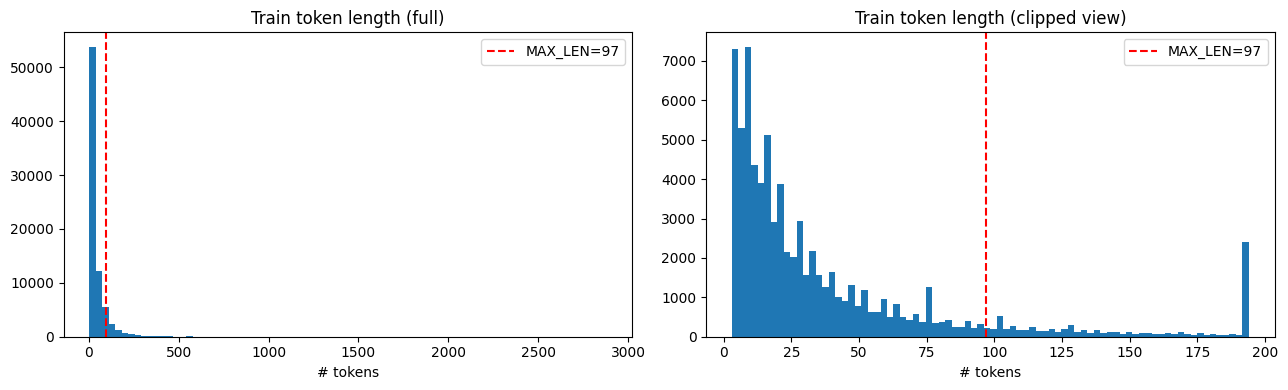

In [11]:
train_lens = train_df['n_tokens']
print('Train token-length stats:')
print(train_lens.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

p90 = int(np.percentile(train_lens, 90))
p95 = int(np.percentile(train_lens, 95))
p99 = int(np.percentile(train_lens, 99))
print(f'\nP90: {p90}   P95: {p95}   P99: {p99}')

# MAX_LEN policy: aim for P90 of the (now possibly larger) enriched token
# distribution, clamped to [MAX_LEN_FLOOR, MAX_LEN_CAP]. P90 instead of P95
# is intentional: with comment-first ordering, anything past MAX_LEN clips
# (less critical) parent context, not the labeled comment text. Capping at
# MAX_LEN_CAP keeps the LSTM compute manageable on CPU.
MAX_LEN = int(min(max(p90, CONFIG['MAX_LEN_FLOOR']), CONFIG['MAX_LEN_CAP']))
CONFIG['MAX_LEN'] = MAX_LEN
print(f'\nUsing MAX_LEN = {MAX_LEN}  (floor={CONFIG["MAX_LEN_FLOOR"]}, cap={CONFIG["MAX_LEN_CAP"]})')
print(f'Fraction of train sequences hitting MAX_LEN: '
      f'{(train_lens >= MAX_LEN).mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train_lens, bins=80)
axes[0].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[0].set_title('Train token length (full)')
axes[0].set_xlabel('# tokens')
axes[0].legend()

clipped = train_lens.clip(upper=MAX_LEN * 2)
axes[1].hist(clipped, bins=80)
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Train token length (clipped view)')
axes[1].set_xlabel('# tokens')
axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Keras Tokenizer and Padded Sequences

Tokenizer is fit on **train only**. `filters=''` and `lower=False` prevent it from re-stripping the `[SEP]` placeholder or undoing case decisions already made.


In [12]:
train_token_strings = train_df['tokens'].apply(lambda toks: ' '.join(toks)).tolist()
val_token_strings   = val_df['tokens'].apply(lambda toks: ' '.join(toks)).tolist()
test_token_strings  = test_df['tokens'].apply(lambda toks: ' '.join(toks)).tolist()

tokenizer = Tokenizer(filters='', lower=False, oov_token='<OOV>')
tokenizer.fit_on_texts(train_token_strings)

vocab_size = len(tokenizer.word_index) + 1
print(f'Vocab size (incl. pad+OOV): {vocab_size}')

X_train_seq = tokenizer.texts_to_sequences(train_token_strings)
X_val_seq   = tokenizer.texts_to_sequences(val_token_strings)
X_test_seq  = tokenizer.texts_to_sequences(test_token_strings)

X_train = pad_sequences(X_train_seq, maxlen=CONFIG['MAX_LEN'], padding='post', truncating='post')
X_val   = pad_sequences(X_val_seq,   maxlen=CONFIG['MAX_LEN'], padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=CONFIG['MAX_LEN'], padding='post', truncating='post')

y_train = train_df['label'].values.astype('float32')
y_val   = val_df['label'].values.astype('float32')
y_test  = test_df['label'].values.astype('float32')

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

oov_idx = tokenizer.word_index.get('<OOV>')
def oov_fraction(seqs, oov_id):
    total = sum(len(s) for s in seqs)
    if total == 0 or oov_id is None:
        return 0.0
    oov = sum(1 for s in seqs for i in s if i == oov_id)
    return oov / total

print(f'\nOOV fraction (train): {oov_fraction(X_train_seq, oov_idx):.4f}')
print(f'OOV fraction (val):   {oov_fraction(X_val_seq, oov_idx):.4f}')
print(f'OOV fraction (test):  {oov_fraction(X_test_seq, oov_idx):.4f}')

with open(os.path.join(CONFIG['ARTIFACTS_DIR'], 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)


Vocab size (incl. pad+OOV): 65995
X_train: (77682, 97)  y_train: (77682,)
X_val:   (9997, 97)    y_val:   (9997,)
X_test:  (9997, 97)   y_test:  (9997,)

OOV fraction (train): 0.0000
OOV fraction (val):   0.0113
OOV fraction (test):  0.0115


## 10. CBOW Word2Vec Training (Train Corpus Only)


In [13]:
train_tokens_list = train_df['tokens'].tolist()
print(f'Sentences for Word2Vec: {len(train_tokens_list)}')

w2v = Word2Vec(
    sentences=train_tokens_list,
    vector_size=CONFIG['EMBED_DIM'],
    window=CONFIG['W2V_WINDOW'],
    min_count=CONFIG['W2V_MIN_COUNT'],
    workers=4,
    sg=CONFIG['W2V_SG'],   # 0 = CBOW (required)
    epochs=CONFIG['W2V_EPOCHS'],
    seed=SEED,
)
assert CONFIG['W2V_SG'] == 0, 'CBOW is mandatory'

print(f'W2V vocab size: {len(w2v.wv)}')
w2v.save(os.path.join(CONFIG['ARTIFACTS_DIR'], 'w2v_cbow.model'))

probe_words = ['trump', 'biden', 'tax', 'gun', 'liber', 'conserv', PLACEHOLDER]
for w in probe_words:
    if w in w2v.wv:
        print(f"\nNearest to '{w}':")
        for sim_word, score in w2v.wv.most_similar(w, topn=5):
            print(f'  {sim_word:>20s}  {score:.3f}')
    else:
        print(f"\n'{w}' not in W2V vocab")


Sentences for Word2Vec: 77682
W2V vocab size: 65993

Nearest to 'trump':
                donald  0.557
                 putin  0.547
                  cruz  0.491
                45,429  0.488
                kasich  0.480

Nearest to 'biden':
                    vp  0.651
              o'malley  0.615
               kirsten  0.608
                warren  0.606
                 kaine  0.604

Nearest to 'tax':
              taxation  0.611
              dividend  0.598
           drastically  0.572
            disposable  0.515
                income  0.510

Nearest to 'gun':
               firearm  0.754
                  guns  0.646
                pistol  0.632
               conceal  0.605
                    ar  0.583

'liber' not in W2V vocab

Nearest to 'conserv':
               come-on  0.895
              20action  0.887
               move-on  0.886
               ^^^this  0.885
           exacerbates  0.884

Nearest to 'xxsepxx':
                 guess  0.471
                

## 11. Embedding Matrix Construction


In [14]:
embedding_matrix = np.zeros((vocab_size, CONFIG['EMBED_DIM']), dtype='float32')
hits = 0
for word, idx in tokenizer.word_index.items():
    if word in w2v.wv:
        embedding_matrix[idx] = w2v.wv[word]
        hits += 1

embedding_matrix[0] = 0.0  # padding row stays zero

coverage = hits / max(vocab_size - 1, 1)
print(f'Embedding matrix shape: {embedding_matrix.shape}')
print(f'W2V coverage (overall): {coverage:.4f} ({hits}/{vocab_size - 1})')

# Per-band W2V coverage. tokenizer.word_index is rank-ordered by frequency
# (Keras assigns idx=1 to the most frequent token, then 2, etc.). Reporting
# coverage by frequency band makes it clear whether the OOV problem is in
# the head (real concern) or in the long tail (mostly harmless after W2V
# min_count=1 + trainable embeddings).
ranked = sorted(tokenizer.word_index.items(), key=lambda kv: kv[1])

def _band_cov(band):
    if not band:
        return 0.0
    return sum(1 for w, _ in band if w in w2v.wv) / len(band)

bands = [
    ('top-1k',   ranked[:1000]),
    ('top-10k',  ranked[1000:10000]),
    ('rest',     ranked[10000:]),
]
for name, band in bands:
    print(f'  band {name:>7}  size={len(band):>6}  coverage={_band_cov(band):.4f}')

# Sample of frequent OOV words (these never received a W2V vector — they will
# be initialized to zeros and learned during model training).
oov_head = [w for w, _ in ranked[:5000] if w not in w2v.wv][:20]
if oov_head:
    print(f'\nSample OOV-in-top-5k tokens (first 20): {oov_head}')

np.save(os.path.join(CONFIG['ARTIFACTS_DIR'], 'embedding_matrix.npy'), embedding_matrix)

assert embedding_matrix.shape == (vocab_size, CONFIG['EMBED_DIM'])
assert np.all(embedding_matrix[0] == 0.0)


Embedding matrix shape: (65995, 100)
W2V coverage (overall): 1.0000 (65993/65994)
  band  top-1k  size=  1000  coverage=0.9990
  band top-10k  size=  9000  coverage=1.0000
  band    rest  size= 55994  coverage=1.0000

Sample OOV-in-top-5k tokens (first 20): ['<OOV>']


## 12. CNN-LSTM Model Definition

Architecture: `Embedding (W2V init, trainable) → SpatialDropout1D → Conv1D → MaxPooling1D → LSTM → Dropout → Dense(sigmoid)`.


In [15]:
class SimpleAttention(Layer):
    """Bahdanau-style additive attention over a sequence.

    Pipeline per timestep t:
        u_t = tanh(W * h_t + b)          # (B, T, units)
        e_t = v * u_t                    # (B, T, 1)
        a_t = softmax_t(e_t)             # (B, T, 1)
        out = sum_t a_t * h_t            # (B, D)

    Output is a context vector — one per example — that summarizes the
    most polarity-relevant tokens, rather than collapsing on the last hidden
    state. Adds ~33k params at units=64 over a 256-D BiLSTM output.
    """

    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        d_in = input_shape[-1]
        self.W = self.add_weight(
            name='att_W',
            shape=(d_in, self.units),
            initializer='glorot_uniform',
        )
        self.b = self.add_weight(
            name='att_b',
            shape=(self.units,),
            initializer='zeros',
        )
        self.v = self.add_weight(
            name='att_v',
            shape=(self.units, 1),
            initializer='glorot_uniform',
        )
        super().build(input_shape)

    def call(self, inputs):
        # inputs: (B, T, D)
        u = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)  # (B, T, U)
        scores = tf.tensordot(u, self.v, axes=1)                    # (B, T, 1)
        weights = tf.nn.softmax(scores, axis=1)                     # (B, T, 1)
        context = tf.reduce_sum(weights * inputs, axis=1)           # (B, D)
        return context

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        cfg = super().get_config()
        cfg['units'] = self.units
        return cfg


def build_cnn_bilstm_attn(vocab_size, embed_dim, max_len, embedding_matrix, config):
    """Embedding -> SpatialDropout -> Conv1D -> MaxPool -> BiLSTM(seq) ->
    concat[last, GlobalMaxPool, SimpleAttention] -> Dropout -> Dense(sigmoid)

    The triple-head summary captures three complementary signals:
      - last hidden state (BiLSTM context at the final timestep)
      - GlobalMaxPool   (most salient token activation per channel)
      - SimpleAttention (learned weighted average over timesteps)
    """
    inp = Input(shape=(max_len,), name='input_ids')
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True,
        mask_zero=False,
        name='embedding',
    )(inp)
    x = SpatialDropout1D(config['SPATIAL_DROPOUT'])(x)
    x = Conv1D(
        filters=config['CONV_FILTERS'],
        kernel_size=config['KERNEL_SIZE'],
        padding='same',
        activation='relu',
        name='conv1d',
    )(x)
    x = MaxPooling1D(pool_size=config['POOL_SIZE'], name='maxpool')(x)

    seq = Bidirectional(
        LSTM(
            config['LSTM_UNITS'],
            dropout=0.2,
            recurrent_dropout=0.0,
            return_sequences=True,
        ),
        name='bilstm',
    )(x)  # (B, T, 2*LSTM_UNITS)

    last = Lambda(lambda t: t[:, -1, :], name='last_step')(seq)
    mx   = GlobalMaxPooling1D(name='global_max')(seq)
    attn = SimpleAttention(units=config['ATTENTION_UNITS'], name='attention')(seq)

    h = Concatenate(name='summary')([last, mx, attn])
    h = Dropout(config['DROPOUT'])(h)
    out = Dense(1, activation='sigmoid', name='output')(h)
    return Model(inp, out, name='cnn_bilstm_attn')


model = build_cnn_bilstm_attn(
    vocab_size=vocab_size,
    embed_dim=CONFIG['EMBED_DIM'],
    max_len=CONFIG['MAX_LEN'],
    embedding_matrix=embedding_matrix,
    config=CONFIG,
)
model.compile(
    optimizer=Adam(learning_rate=CONFIG['LR']),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
model.summary()




Model: "cnn_bilstm_attn"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 97)]                 0         []                            
                                                                                                  
 embedding (Embedding)       (None, 97, 100)              6599500   ['input_ids[0][0]']           
                                                                                                  
 spatial_dropout1d (Spatial  (None, 97, 100)              0         ['embedding[0][0]']           
 Dropout1D)                                                                                       
                                                                                                  
 conv1d (Conv1D)             (None, 97, 128)              64128     ['spatial_drop

## 13. Training Callbacks


In [16]:
best_path = os.path.join(CONFIG['ARTIFACTS_DIR'], 'best_model.keras')

# Callback strategy:
# - Monitor val_loss everywhere (smoother and less stepwise than val_accuracy,
#   which is sensitive to threshold decisions at p=0.5 and to BiLSTM noise).
# - Longer ES patience: the larger triple-head BiLSTM plateaus longer before
#   its final improvements.
# - LR floor is 1e-6 (was 1e-5) so the optimizer can keep crawling.
# - TerminateOnNaN is added as a cheap safety net for the bigger model.
callbacks = [
    ModelCheckpoint(
        filepath=best_path,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=CONFIG['PATIENCE_ES'],
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=CONFIG['PATIENCE_LR'],
        min_lr=1e-6,
        verbose=1,
    ),
    TerminateOnNaN(),
]
print(f'Best model will be saved to: {best_path}')


Best model will be saved to: artifacts\best_model.keras


## 14. Model Training


In [17]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG['EPOCHS'],
    batch_size=CONFIG['BATCH_SIZE'],
    callbacks=callbacks,
    shuffle=True,
    verbose=2,
)

hist_path = os.path.join(CONFIG['ARTIFACTS_DIR'], 'history.json')
with open(hist_path, 'w') as f:
    json.dump(
        {k: [float(x) for x in v] for k, v in history.history.items()},
        f, indent=2,
    )

print(f'\nTrained for {len(history.history["loss"])} epochs')
print(f'Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')


Epoch 1/30



Epoch 1: val_loss improved from inf to 0.58718, saving model to artifacts\best_model.keras
1214/1214 - 106s - loss: 0.6213 - accuracy: 0.6375 - val_loss: 0.5872 - val_accuracy: 0.6722 - lr: 0.0010 - 106s/epoch - 87ms/step
Epoch 2/30

Epoch 2: val_loss improved from 0.58718 to 0.57223, saving model to artifacts\best_model.keras
1214/1214 - 102s - loss: 0.5882 - accuracy: 0.6738 - val_loss: 0.5722 - val_accuracy: 0.6810 - lr: 0.0010 - 102s/epoch - 84ms/step
Epoch 3/30

Epoch 3: val_loss improved from 0.57223 to 0.56333, saving model to artifacts\best_model.keras
1214/1214 - 103s - loss: 0.5654 - accuracy: 0.6936 - val_loss: 0.5633 - val_accuracy: 0.6846 - lr: 0.0010 - 103s/epoch - 85ms/step
Epoch 4/30

Epoch 4: val_loss did not improve from 0.56333
1214/1214 - 104s - loss: 0.5383 - accuracy: 0.7207 - val_loss: 0.5687 - val_accuracy: 0.6869 - lr: 0.0010 - 104s/epoch - 86ms/step
Epoch 5/30

Epoch 5: val_loss improved from 0.56333 to 0.55606, saving model to artifacts\best_mod

## 15. Training & Validation Curves


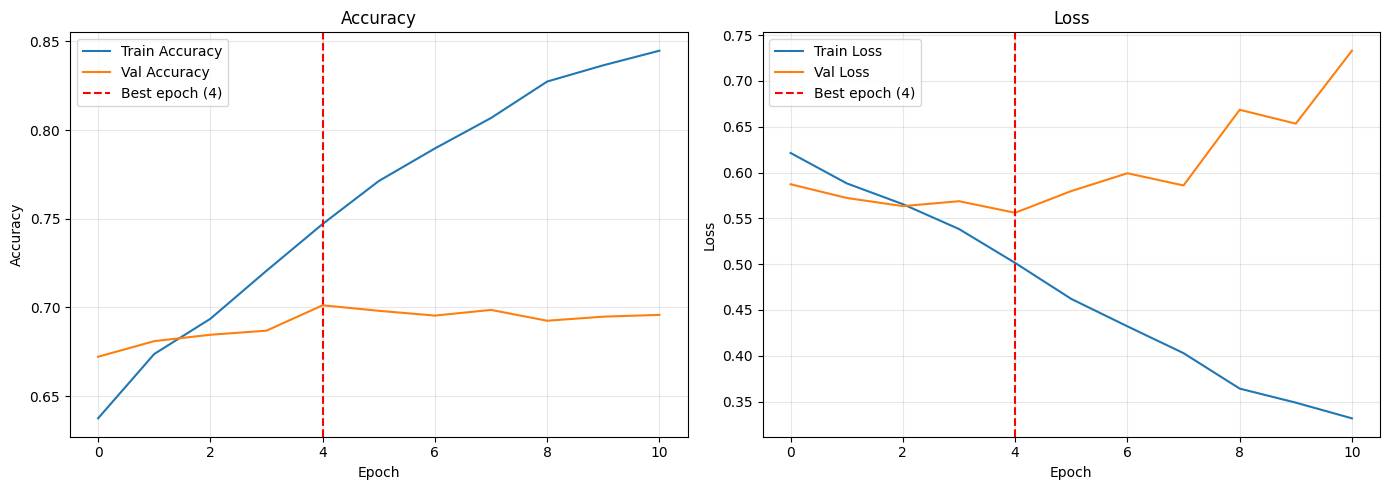

In [18]:
hist = history.history
best_ep = int(np.argmax(hist['val_accuracy']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist['accuracy'], label='Train Accuracy')
axes[0].plot(hist['val_accuracy'], label='Val Accuracy')
axes[0].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch ({best_ep})')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist['loss'], label='Train Loss')
axes[1].plot(hist['val_loss'], label='Val Loss')
axes[1].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch ({best_ep})')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
best_model = load_model(
    best_path,
    custom_objects={'SimpleAttention': SimpleAttention},
    safe_mode=False
)

val_prob = best_model.predict(
    X_val,
    batch_size=CONFIG['BATCH_SIZE'],
    verbose=1
).ravel()

y_val_int = y_val.astype(int)

thresholds = np.arange(0.20, 0.801, 0.005)

sweep = []

for t in thresholds:
    pred = (val_prob >= t).astype(int)

    sweep.append((
        float(t),
        float(f1_score(y_val_int, pred, average='macro')),
        float(accuracy_score(y_val_int, pred)),
    ))

best_thr, best_f1m, best_acc = max(sweep, key=lambda x: x[1])

print(
    f'Best threshold by val macro-F1: {best_thr:.3f} '
    f'(val macro-F1 = {best_f1m:.4f}, val acc = {best_acc:.4f})'
)

print('\nSweep summary (every 0.05):')
print(f'{"thr":>6}  {"macroF1":>8}  {"acc":>8}')

for t, m, a in sweep[::10]:
    marker = ' <-- best' if abs(t - best_thr) < 1e-6 else ''
    print(f'{t:>6.3f}  {m:>8.4f}  {a:>8.4f}{marker}')

CONFIG['BEST_THR'] = best_thr

157/157 [==============================] - 3s 17ms/step
Best threshold by val macro-F1: 0.510 (val macro-F1 = 0.7035, val acc = 0.7035)

Sweep summary (every 0.05):
   thr   macroF1       acc
 0.200    0.5781    0.6259
 0.250    0.6095    0.6439
 0.300    0.6364    0.6594
 0.350    0.6607    0.6748
 0.400    0.6806    0.6873
 0.450    0.6959    0.6976
 0.500    0.7012    0.7012
 0.550    0.7005    0.7013
 0.600    0.6906    0.6943
 0.650    0.6796    0.6878
 0.700    0.6635    0.6775
 0.750    0.6398    0.6629
 0.800    0.6096    0.6443


## 16. Final Test Evaluation


In [22]:
# best_model and best_thr are set by the threshold-sweep cell above.
# Reload the model defensively so this cell can also be run standalone.

best_model = load_model(
    best_path,
    custom_objects={'SimpleAttention': SimpleAttention},
    safe_mode=False
)

y_prob = best_model.predict(
    X_test,
    batch_size=CONFIG['BATCH_SIZE'],
    verbose=1
).ravel()

chosen_thr = float(CONFIG.get('BEST_THR', 0.5))

y_pred = (y_prob >= chosen_thr).astype(int)
y_true = y_test.astype(int)

# comparison @0.5
y_pred_05 = (y_prob >= 0.5).astype(int)

acc        = accuracy_score(y_true, y_pred)
prec_rep   = precision_score(y_true, y_pred, pos_label=1)
rec_rep    = recall_score(y_true, y_pred, pos_label=1)
f1_rep     = f1_score(y_true, y_pred, pos_label=1)

prec_macro = precision_score(y_true, y_pred, average='macro')
rec_macro  = recall_score(y_true, y_pred, average='macro')
f1_macro   = f1_score(y_true, y_pred, average='macro')

print(f'Chosen threshold (from val sweep): {chosen_thr:.3f}')
print(f'Test Accuracy:           {acc:.4f}')
print(f'Test Precision (Rep):    {prec_rep:.4f}')
print(f'Test Recall    (Rep):    {rec_rep:.4f}')
print(f'Test F1        (Rep):    {f1_rep:.4f}')
print(f'Test Precision (macro):  {prec_macro:.4f}')
print(f'Test Recall    (macro):  {rec_macro:.4f}')
print(f'Test F1        (macro):  {f1_macro:.4f}')

print('\nClassification report:')
print(classification_report(
    y_true,
    y_pred,
    target_names=['Democrat', 'Republican'],
    digits=4
))

acc_05 = accuracy_score(y_true, y_pred_05)
f1m_05 = f1_score(y_true, y_pred_05, average='macro')

print(f'@thr=0.500  acc={acc_05:.4f}  macroF1={f1m_05:.4f}')
print(f'@thr={chosen_thr:.3f}  acc={acc:.4f}  macroF1={f1_macro:.4f}')

results = {
    'accuracy': float(acc),
    'precision_republican': float(prec_rep),
    'recall_republican': float(rec_rep),
    'f1_republican': float(f1_rep),
    'precision_macro': float(prec_macro),
    'recall_macro': float(rec_macro),
    'f1_macro': float(f1_macro),
    'threshold': float(chosen_thr),
    'accuracy_at_0.5': float(acc_05),
    'f1_macro_at_0.5': float(f1m_05),
    'n_test': int(len(y_true)),
    'max_len': int(CONFIG['MAX_LEN']),
    'vocab_size': int(vocab_size),
}

with open(
    os.path.join(CONFIG['ARTIFACTS_DIR'], 'test_metrics.json'),
    'w'
) as f:
    json.dump(results, f, indent=2)

157/157 [==============================] - 3s 16ms/step
Chosen threshold (from val sweep): 0.510
Test Accuracy:           0.6919
Test Precision (Rep):    0.6951
Test Recall    (Rep):    0.6837
Test F1        (Rep):    0.6894
Test Precision (macro):  0.6920
Test Recall    (macro):  0.6919
Test F1        (macro):  0.6919

Classification report:
              precision    recall  f1-score   support

    Democrat     0.6888    0.7001    0.6944      4998
  Republican     0.6951    0.6837    0.6894      4999

    accuracy                         0.6919      9997
   macro avg     0.6920    0.6919    0.6919      9997
weighted avg     0.6920    0.6919    0.6919      9997

@thr=0.500  acc=0.6912  macroF1=0.6912
@thr=0.510  acc=0.6919  macroF1=0.6919


## 17. Confusion Matrix Visualization


Confusion matrix (rows = true, cols = predicted):
[[3499 1499]
 [1581 3418]]


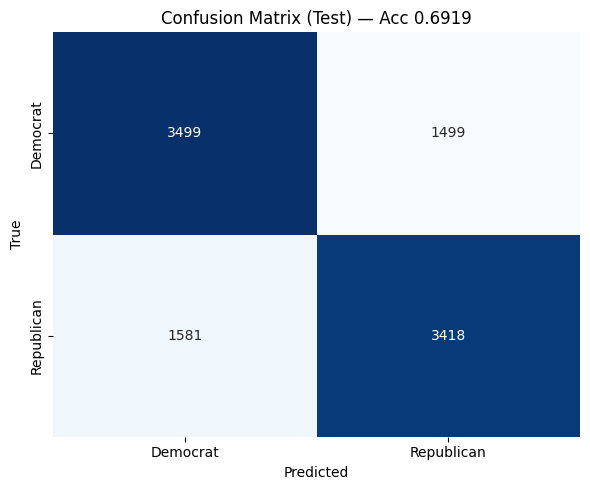

In [23]:
cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix (rows = true, cols = predicted):')
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Democrat', 'Republican'],
    yticklabels=['Democrat', 'Republican'],
    ax=ax, cbar=False,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (Test) — Acc {acc:.4f}')
plt.tight_layout()
plt.show()


## 18. Error Analysis / Sample Predictions


In [24]:
analysis_df = test_df.copy().reset_index(drop=True)
analysis_df['y_true'] = y_true
analysis_df['y_pred'] = y_pred
analysis_df['y_prob'] = y_prob
analysis_df['correct'] = (analysis_df['y_true'] == analysis_df['y_pred'])
analysis_df['margin']  = (analysis_df['y_prob'] - 0.5).abs()

print(f'Total test rows:   {len(analysis_df)}')
print(f'Correct:           {int(analysis_df["correct"].sum())} '
      f'({analysis_df["correct"].mean():.4f})')
print(f'has_context frac:  {analysis_df["has_context"].mean():.4f}')

print('\nAccuracy by has_context:')
print(analysis_df.groupby('has_context')['correct'].agg(['mean', 'count']))

print('\nAccuracy by true label:')
print(analysis_df.groupby('y_true')['correct'].agg(['mean', 'count']))


Total test rows:   9997
Correct:           6917 (0.6919)
has_context frac:  0.1260

Accuracy by has_context:
                mean  count
has_context                
False        0.67506   8737
True         0.80873   1260

Accuracy by true label:
            mean  count
y_true                 
0       0.700080   4998
1       0.683737   4999


In [25]:
def show(rows, title):
    print('\n' + '=' * 78)
    print(title)
    print('=' * 78)
    for _, r in rows.iterrows():
        print(
            f"\n[true={int(r['y_true'])} pred={int(r['y_pred'])} "
            f"prob={r['y_prob']:.3f} has_context={bool(r['has_context'])}]"
        )
        text = r['enriched_text']
        print(text[:400] + ('...' if len(text) > 400 else ''))

top_correct_rep = analysis_df[(analysis_df['correct']) & (analysis_df['y_true'] == 1)].nlargest(5, 'y_prob')
top_correct_dem = analysis_df[(analysis_df['correct']) & (analysis_df['y_true'] == 0)].nsmallest(5, 'y_prob')
top_wrong_rep   = analysis_df[(~analysis_df['correct']) & (analysis_df['y_true'] == 1)].nsmallest(5, 'y_prob')
top_wrong_dem   = analysis_df[(~analysis_df['correct']) & (analysis_df['y_true'] == 0)].nlargest(5, 'y_prob')
ambiguous       = analysis_df.nsmallest(5, 'margin')

show(top_correct_rep, 'Top confident CORRECT — Republican')
show(top_correct_dem, 'Top confident CORRECT — Democrat')
show(top_wrong_rep,   'Top confident WRONG  — Republican (predicted Democrat)')
show(top_wrong_dem,   'Top confident WRONG  — Democrat (predicted Republican)')
show(ambiguous,       'Most ambiguous predictions (prob near 0.5)')

err_path = os.path.join(CONFIG['ARTIFACTS_DIR'], 'error_analysis.csv')
analysis_df[[
    'text', 'enriched_text', 'has_context',
    'y_true', 'y_pred', 'y_prob', 'correct', 'margin',
]].to_csv(err_path, index=False)
print(f'\nFull error analysis saved to: {err_path}')



Top confident CORRECT — Republican

[true=1 pred=1 prob=0.999 has_context=False]
Hello, and welcome to /r/Republican.
Please understand this subreddit's primary purpose is for Republicans to discuss issues facing the party. Out of respect for this sub's main topic, we ask that [unless you identify as Republican that you leave the vote button alone](https://www.reddit.com/r/MetaRepublican/comments/5t017a/this_sub_is_for_republicans_if_you_do_not/). Non republicans who come to o...

[true=1 pred=1 prob=0.999 has_context=False]
Hello, and welcome to /r/Republican.
Please understand this subreddit's primary purpose is for Republicans to discuss issues facing the party. Out of respect for this sub's main topic, we ask that [unless you identify as Republican that you leave the vote button alone](https://www.reddit.com/r/MetaRepublican/comments/5t017a/this_sub_is_for_republicans_if_you_do_not/). Non republicans who come to o...

[true=1 pred=1 prob=0.999 has_context=False]
Hello, and welcome

## Done

Artifacts saved under `artifacts/`:

- `posts_context.pkl` — id → post text dictionary
- `tokenizer.pkl` — Keras tokenizer fit on train
- `w2v_cbow.model` — domain-specific CBOW Word2Vec
- `embedding_matrix.npy` — aligned embedding matrix
- `best_model.keras` — best validation checkpoint
- `history.json` — training curves
- `test_metrics.json` — final test metrics
- `error_analysis.csv` — per-row test predictions for inspection
